In [1]:
from tool1 import *
set_seed(0)

## requires_grad 


In [ ]:
x = torch.tensor(3.0, requires_grad=True)
y = x**2 + 2 * x + 1
print('y:', y)
y.backward()

print('x.grad:', x.grad.item(), 'dy/dx:', 2 * x.item() + 2)
# y.grad

y: tensor(16., grad_fn=<AddBackward0>)
x.grad: 8.0 dy/dx: 8.0


In [8]:
w = torch.tensor([1.0, 2.0, 3.0], requires_grad=True)
b = torch.tensor(0.5, requires_grad=True)
x = torch.tensor([0.5, 1.0, 1.5])
y = (w * x).sum() + b
y.backward()
print('w.grad:', w.grad)
print('b.grad:', b.grad)

w.grad: tensor([0.5000, 1.0000, 1.5000])
b.grad: tensor(1.)


In [13]:
# Zero Grad 누적
w = torch.tensor(1.0, requires_grad=True)
for step in range(3):
    loss = (w - 2.0) ** 2
    loss.backward()
    print(f'end=step{step}, w.grad={w.grad.item()}')

w.grad = None
for step in range(3):
    loss = (w - 2.0) ** 2
    loss.backward()
    print(f'end=step{step}, w.grad={w.grad.item()}')
    w.grad = None

end=step0, w.grad=-2.0
end=step1, w.grad=-4.0
end=step2, w.grad=-6.0
end=step0, w.grad=-2.0
end=step1, w.grad=-2.0
end=step2, w.grad=-2.0


In [15]:
a = torch.tensor(2.0, requires_grad=True)
b = a * 3
c = b * b
c.backward()

print('a.grad:', a.grad)
print('b.grad:', b.grad)
print('c.grad:', c.grad)


a.grad: tensor(36.)
b.grad: None
c.grad: None


/tmp/ipykernel_65197/236901960.py:7: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more information. (Triggered internally at /pytorch/build/aten/src/ATen/core/TensorBody.h:494.)
  print('b.grad:', b.grad)
/tmp/ipykernel_65197/236901960.py:8: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/py

In [19]:
x = torch.tensor(2.0, requires_grad=True)
# print(x.requires_grad)
with torch.no_grad():
    y = x * 3
    print('y.requires_grad:', y.requires_grad)

z = (x * 5).detach()
print('z.requires_grad:', z.requires_grad)


y.requires_grad: False
z.requires_grad: False


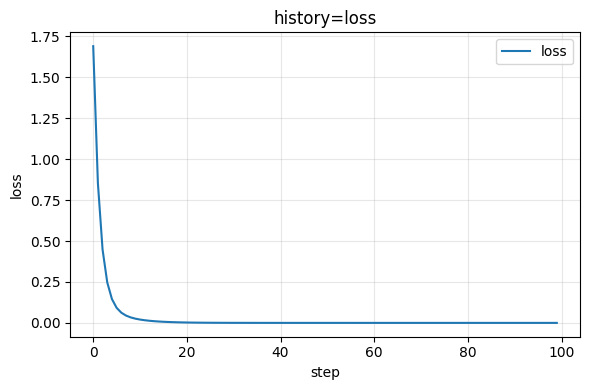

In [23]:
# Mini Gradient Descent 
x = torch.linspace(-3, 3, 50).unsqueeze(1)
y_true = 0.7 * x + 0.4

w = torch.tensor(0.0, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)
lr = 0.05
losses = []
for step in range(100):
    y_pred = w * x + b
    loss = ((y_true - y_pred) ** 2).mean()
    loss.backward()
    
    with torch.no_grad():
        w -= lr * w.grad
        b -= lr * b.grad
        
        w.grad = None
        b.grad = None
    losses.append(loss.item())
plot_loss(losses, title='history=loss')